# KPI Visualizations for Models A, B, C

Notebook phụ trợ để khám phá dữ liệu train cho 3 model:
- **A (Intern)** – data_A.csv
- **B (Experienced)** – data_B.csv
- **C (Internal)** – data_C.csv

Chạy notebook này sau khi đã sinh dữ liệu từ `generate_data.py`.

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

# Nếu bạn chạy notebook trong môi trường chưa có thư viện, cài nhanh:
# !python -m pip install -r requirements.txt

# Đảm bảo import được package src/
# Tự dò lên trên để tìm thư mục có "src" và "data"
ROOT = Path.cwd().resolve()
for _ in range(5):
    if (ROOT / "src").exists() and (ROOT / "data").exists():
        break
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "output"
MODELS_DIR = ROOT / "models"
OUTPUT_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print("ROOT =", ROOT)
print("DATA_DIR =", DATA_DIR)
print("MODELS_DIR =", MODELS_DIR)
print("OUTPUT_DIR =", OUTPUT_DIR)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

ROOT = D:\DoAnTotNghiep\HM
DATA_DIR = D:\DoAnTotNghiep\HM\data
MODELS_DIR = D:\DoAnTotNghiep\HM\models
OUTPUT_DIR = D:\DoAnTotNghiep\HM\output


In [3]:
# Helpers: load data, train LR, and plot ONE report image per model

import joblib
import numpy as np
from IPython.display import Image, display
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.calibration import CalibrationDisplay


def load_csv(name: str) -> pd.DataFrame:
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}. Run generate_data first.")
    return pd.read_csv(path)


def split_xy(df: pd.DataFrame, feature_cols: list[str], kpi_threshold: float):
    X = df[feature_cols].values
    y = (df["KPI"] >= kpi_threshold).astype(int).values
    return X, y


def load_model_bundle(model_key: str) -> dict:
    p = MODELS_DIR / f"model_{model_key}.pkl"
    if not p.exists():
        raise FileNotFoundError(f"Missing model file: {p}. Train first.")
    return joblib.load(p)


def plot_lr_report(model_key: str, X, y, title: str) -> Path:
    """Sinh 1 ảnh report (2x2) cho Logistic Regression và hiển thị ngay trong notebook."""
    bundle = load_model_bundle(model_key)
    pipe = bundle["pipeline"]

    proba = pipe.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)

    fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.5))
    ax = axes[0, 0]
    RocCurveDisplay.from_predictions(y, proba, ax=ax)
    ax.set_title("ROC")

    ax = axes[0, 1]
    ConfusionMatrixDisplay.from_predictions(y, pred, ax=ax, colorbar=False)
    ax.set_title("Confusion Matrix (p>=0.5)")

    ax = axes[1, 0]
    CalibrationDisplay.from_predictions(y, proba, n_bins=10, ax=ax)
    ax.set_title("Calibration")

    ax = axes[1, 1]
    ax.hist(proba[y == 0], bins=30, alpha=0.6, label="y=0", color="tab:blue")
    ax.hist(proba[y == 1], bins=30, alpha=0.6, label="y=1", color="tab:orange")
    ax.set_title("Predicted probability distribution")
    ax.set_xlabel("P(y=1)")
    ax.set_ylabel("Count")
    ax.legend()

    fig.suptitle(f"{title} — Logistic Regression report", y=1.02, fontsize=12)
    fig.tight_layout()

    out = OUTPUT_DIR / f"lr_{model_key}_report.png"
    fig.savefig(out, dpi=130, bbox_inches="tight")
    plt.close(fig)

    display(Image(filename=str(out)))
    print("Saved:", out)
    return out


print("Helpers ready. Run one of the 3 training cells (A/B/C) below.")

Helpers ready. Run one of the 3 training cells (A/B/C) below.


In [5]:
# Load data (A/B/C) + quick KPI histograms (optional)

def plot_kpi_histogram(df: pd.DataFrame, title: str, kpi_max: float, fname: str):
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.hist(df["KPI"], bins=40, color="steelblue", edgecolor="white", alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("KPI")
    ax.set_ylabel("Count")
    ax.set_xlim(0, kpi_max)
    fig.tight_layout()
    out = OUTPUT_DIR / fname
    fig.savefig(out)
    plt.close(fig)
    print("Saved:", out)


a = load_csv("data_A.csv")
print("A shape:", a.shape)
display(a.head())

b = load_csv("data_B.csv")
print("B shape:", b.shape)
display(b.head())

c = load_csv("data_C.csv")
print("C shape:", c.shape)
display(c.head())

plot_kpi_histogram(a, "Model A (Intern) — KPI in CSV", 0.6, "kpi_A_hist.png")
plot_kpi_histogram(b, "Model B (Experienced) — KPI in CSV", 1.0, "kpi_B_hist.png")
plot_kpi_histogram(c, "Model C (Internal) — KPI in CSV", 1.0, "kpi_C_hist.png")

A shape: (5000, 4)


,GPA,interview_score,CV_score,KPI
0,3.38,6.91,6.91,0.4148
1,3.61,8.04,8.04,0.4822
2,2.36,3.59,2.22,0.0800
3,2.18,2.93,1.61,0.1190
4,2.92,3.78,3.76,0.2364


B shape: (5000, 4)


,GPA,num_projects,years_experience,KPI
0,3.18,2,3.07,0.2364
1,3.45,12,19.80,0.8007
2,3.47,7,19.94,0.7637
3,3.21,7,12.34,0.4944
4,3.62,4,11.47,0.4630


C shape: (5000, 4)


,total_projects,total_tasks,hard_tasks,KPI
0,5,51,11,0.4624
1,1,15,1,0.0796
2,11,299,78,0.8032
3,13,153,32,0.7704
4,11,232,76,0.8440


Saved: D:\DoAnTotNghiep\HM\output\kpi_A_hist.png
Saved: D:\DoAnTotNghiep\HM\output\kpi_B_hist.png
Saved: D:\DoAnTotNghiep\HM\output\kpi_C_hist.png


[train] Đã lưu model → D:\DoAnTotNghiep\HM\models\model_A.pkl (samples=5000)


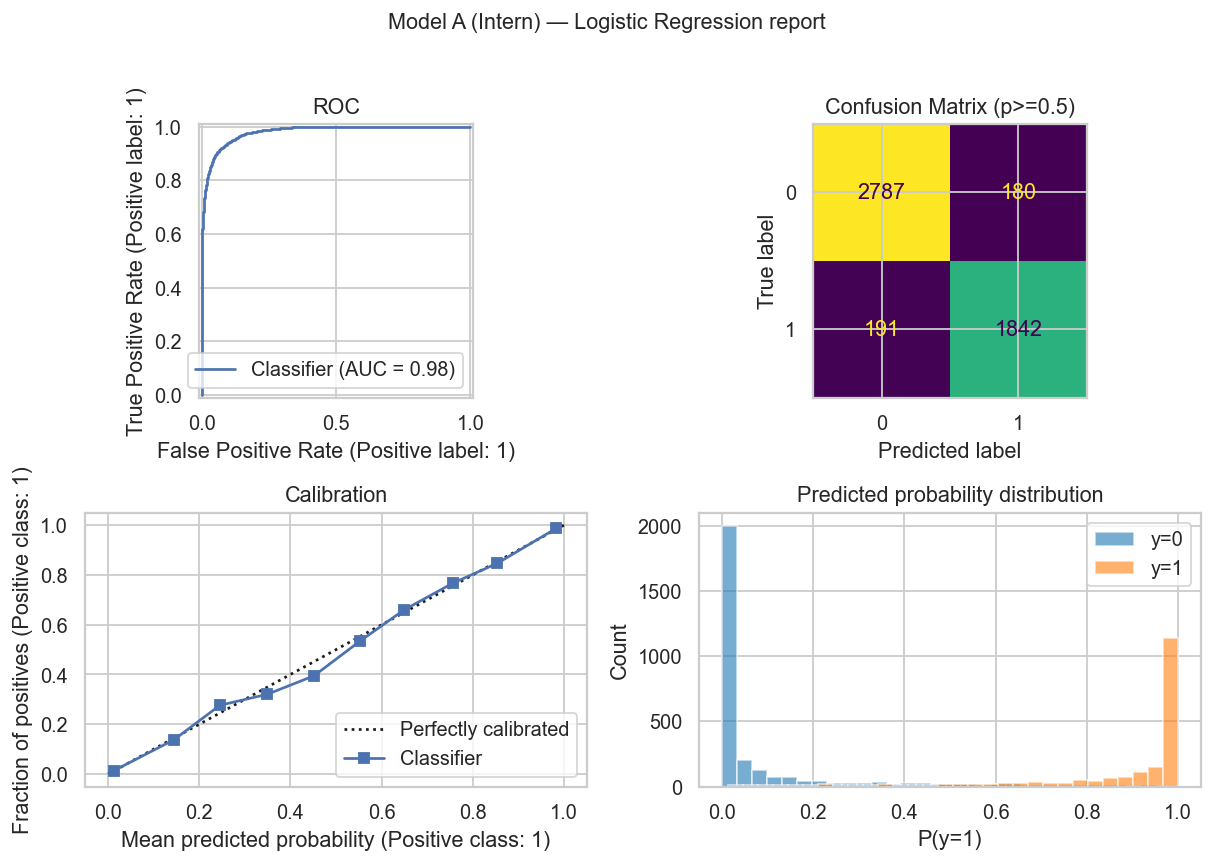

Saved: D:\DoAnTotNghiep\HM\output\lr_A_report.png


WindowsPath('D:/DoAnTotNghiep/HM/output/lr_A_report.png')

In [6]:
# ▶ Button 1: Train Model A (Intern) on data_A.csv  → 1 report image

from src.train_model_A import train as train_a
from src.utils import KPI_TRAIN_THRESHOLD_A

FEATURES_A = ["GPA", "interview_score", "CV_score"]

df_a = load_csv("data_A.csv")
X_a, y_a = split_xy(df_a, FEATURES_A, float(KPI_TRAIN_THRESHOLD_A))

train_a()  # saves HM/models/model_A.pkl
plot_lr_report("A", X_a, y_a, "Model A (Intern)")

[train] Đã lưu model → D:\DoAnTotNghiep\HM\models\model_B.pkl (samples=5000)


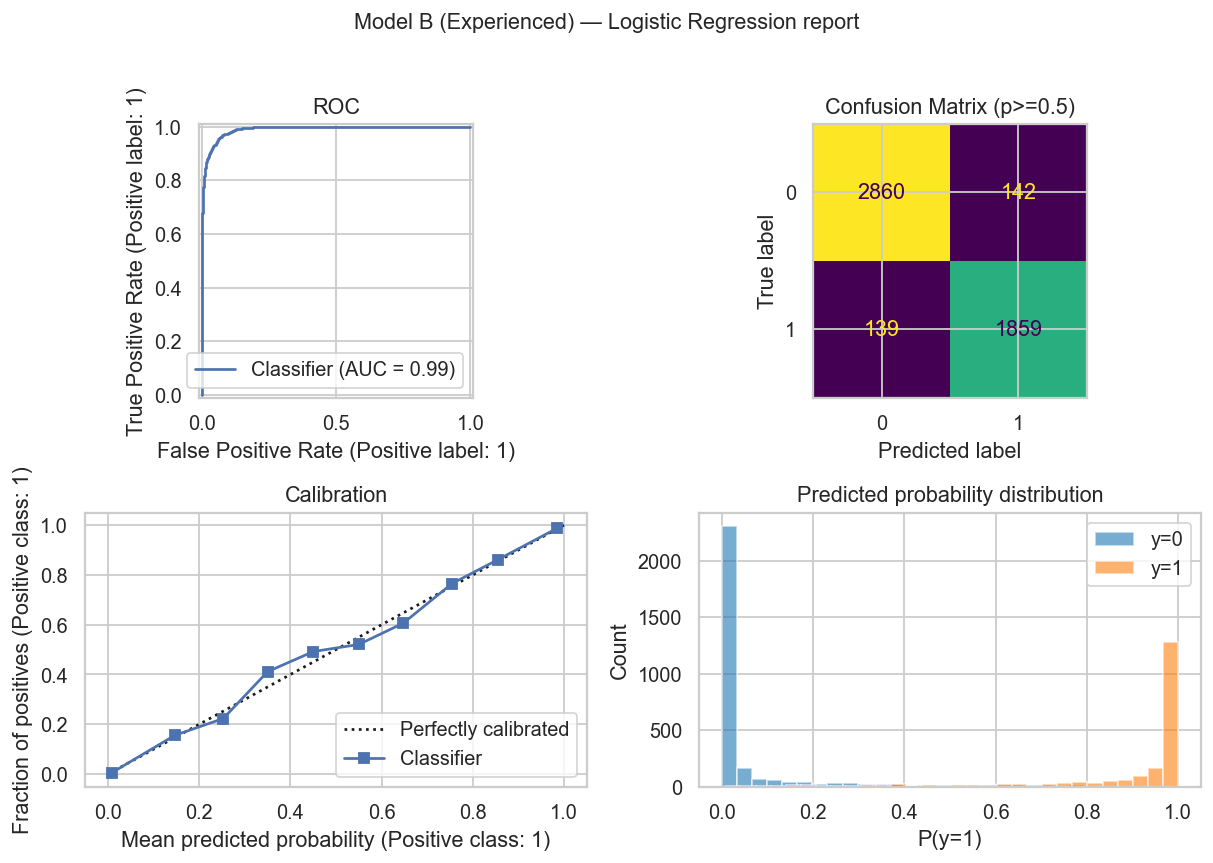

Saved: D:\DoAnTotNghiep\HM\output\lr_B_report.png


WindowsPath('D:/DoAnTotNghiep/HM/output/lr_B_report.png')

In [7]:
# ▶ Button 2: Train Model B (Experienced) on data_B.csv  → 1 report image

from src.train_model_B import train as train_b

FEATURES_B = ["GPA", "num_projects", "years_experience"]

df_b = load_csv("data_B.csv")
X_b, y_b = split_xy(df_b, FEATURES_B, 0.5)

train_b()  # saves HM/models/model_B.pkl
plot_lr_report("B", X_b, y_b, "Model B (Experienced)")

[train] Đã lưu model → D:\DoAnTotNghiep\HM\models\model_C.pkl (samples=5000)


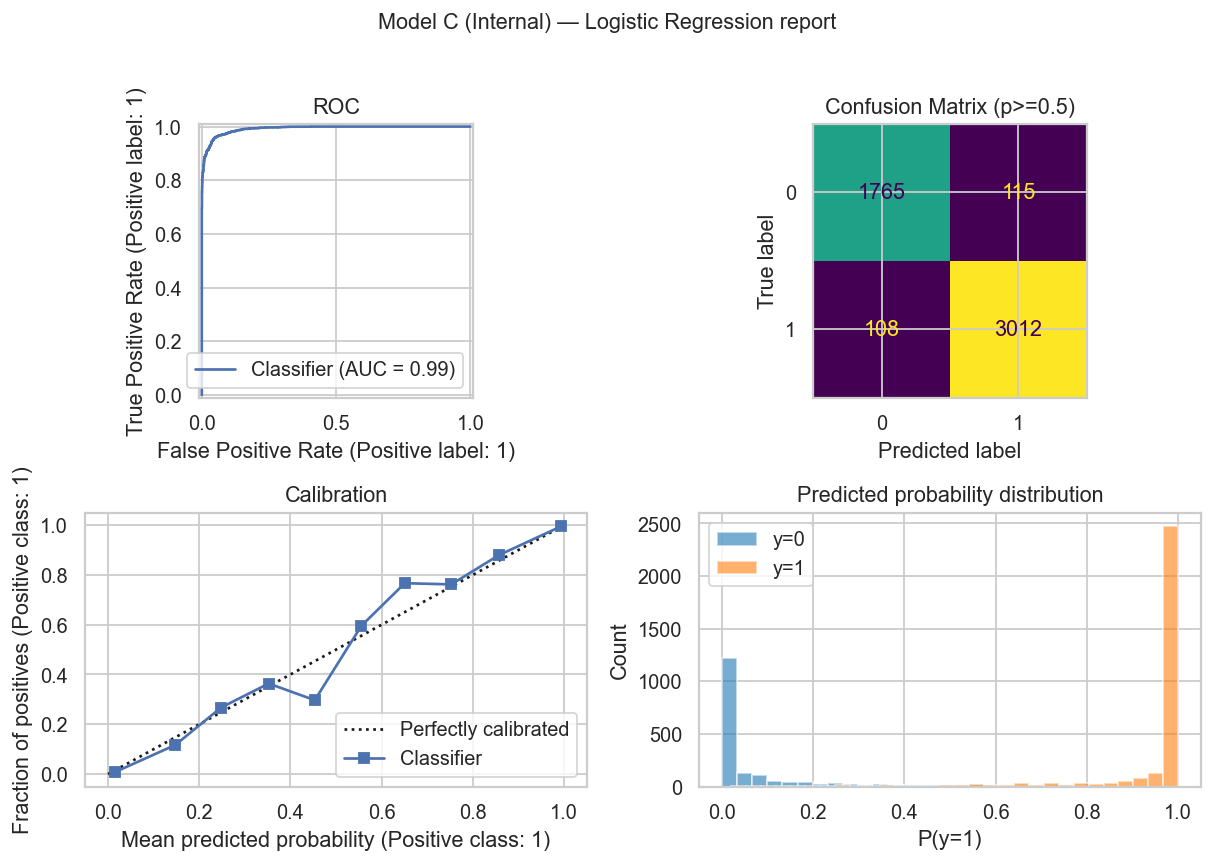

Saved: D:\DoAnTotNghiep\HM\output\lr_C_report.png
Done. Images saved to HM/output as lr_A_report.png / lr_B_report.png / lr_C_report.png


In [8]:
# ▶ Button 3: Train Model C (Internal) on data_C.csv  → 1 report image

from src.train_model_C import train as train_c

FEATURES_C = ["total_projects", "total_tasks", "hard_tasks"]

df_c = load_csv("data_C.csv")
X_c, y_c = split_xy(df_c, FEATURES_C, 0.5)

train_c()  # saves HM/models/model_C.pkl
plot_lr_report("C", X_c, y_c, "Model C (Internal)")

print("Done. Images saved to HM/output as lr_A_report.png / lr_B_report.png / lr_C_report.png")

In [40]:
# === Visual kiểu sigmoid như hình mẫu (3 model riêng) ===
# Ý tưởng: dùng full vector nhiều biến -> tính z = w^T x + b (sau scaler)
# rồi p = sigmoid(z), cuối cùng map sang KPI theo rule business từng model.

import numpy as np
from IPython.display import Image, display
from matplotlib.lines import Line2D

from src.predict import scale_kpi_to_business_range
from src.utils import KPI_TRAIN_THRESHOLD_A


def _pipe_parts(model_key: str):
    bundle = load_model_bundle(model_key)
    pipe = bundle["pipeline"]
    scaler = pipe.named_steps["scaler"]
    clf = pipe.named_steps["clf"]
    return pipe, scaler, clf


def _predict_from_full_vector(model_key: str, feature_cols: list[str], X: np.ndarray):
    """Return z, p, kpi using full multivariate vector."""
    _, scaler, clf = _pipe_parts(model_key)
    Xs = scaler.transform(X)
    z = clf.decision_function(Xs)
    p = 1.0 / (1.0 + np.exp(-z))

    if model_key == "B":
        years = X[:, feature_cols.index("years_experience")]
        kpi = np.array([
            scale_kpi_to_business_range(float(pi), "B", years_experience=float(yy))
            for pi, yy in zip(p, years)
        ], dtype=float)
    else:
        kpi = np.array([scale_kpi_to_business_range(float(pi), model_key) for pi in p], dtype=float)

    return z, p, kpi


def _plot_sigmoid_style_report(
    *,
    model_key: str,
    df,
    feature_cols: list[str],
    kpi_threshold: float,
    title: str,
    out_name: str,
    example_vector: dict,
):
    X = df[feature_cols].values.astype(float)
    y_bin = (df["KPI"].values >= float(kpi_threshold)).astype(int)

    z, p, kpi_pred = _predict_from_full_vector(model_key, feature_cols, X)

    # Chuẩn hóa z về [0,1] để plot kiểu giống hình mẫu
    z_min, z_max = np.percentile(z, 1), np.percentile(z, 99)
    z_range = max(z_max - z_min, 1e-9)
    x_norm = np.clip((z - z_min) / z_range, 0, 1)

    # Curve sigmoid KPI(z)
    x_grid = np.linspace(0, 1, 300)
    z_grid = z_min + x_grid * z_range
    p_grid = 1.0 / (1.0 + np.exp(-z_grid))
    if model_key == "B":
        # Để vẽ 1 đường biên cho B, giữ years_experience ở median data
        years_med = float(df["years_experience"].median())
        kpi_curve = np.array([
            scale_kpi_to_business_range(float(pp), "B", years_experience=years_med)
            for pp in p_grid
        ])
    else:
        kpi_curve = np.array([scale_kpi_to_business_range(float(pp), model_key) for pp in p_grid])

    # ví dụ 1 người
    ex = np.array([[float(example_vector[c]) for c in feature_cols]], dtype=float)
    z_ex, p_ex, kpi_ex = _predict_from_full_vector(model_key, feature_cols, ex)
    x_ex = float(np.clip((z_ex[0] - z_min) / z_range, 0, 1))

    kpi_max = 0.6 if model_key == "A" else (0.9 if model_key == "B" else 1.0)

    fig, ax = plt.subplots(figsize=(8.2, 5.4))

    # scatter dữ liệu
    ax.scatter(x_norm[y_bin == 1], kpi_pred[y_bin == 1], s=8, c="#1f77b4", alpha=0.9)
    ax.scatter(x_norm[y_bin == 0], kpi_pred[y_bin == 0], s=8, c="#d62728", alpha=0.85)

    # sigmoid boundary
    ax.plot(x_grid, kpi_curve, color="#00a86b", linewidth=2.4)

    # example point
    ax.scatter([x_ex], [kpi_ex[0]], s=80, c="gold", edgecolors="black", zorder=6)
    ax.annotate(
        f"Example KPI={float(kpi_ex[0]):.4f}",
        (x_ex, float(kpi_ex[0])),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=9,
        color="black",
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, kpi_max)
    ax.set_xlabel("Normalized linear score z")
    ax.set_ylabel("Predicted KPI")
    ax.set_title(title)

    legend_handles = [
        Line2D([], [], color="#00a86b", marker="o", markersize=0, label="Boundary (sigmoid)", linewidth=2.4),
        Line2D([], [], color="#d62728", marker="o", linestyle="None", markersize=5, label="False samples (y=0)"),
        Line2D([], [], color="#1f77b4", marker="o", linestyle="None", markersize=5, label="True samples (y=1)"),
        Line2D([], [], color="gold", marker="o", markeredgecolor="black", linestyle="None", markersize=7, label="Example"),
    ]
    ax.legend(handles=legend_handles, loc="best")

    fig.tight_layout()
    out = OUTPUT_DIR / out_name
    fig.savefig(out, dpi=140, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(out)))
    print("Saved:", out)


print("Ready: run next 3 cells (A/B/C) to generate 3 images.")

Ready: run next 3 cells (A/B/C) to generate 3 images.


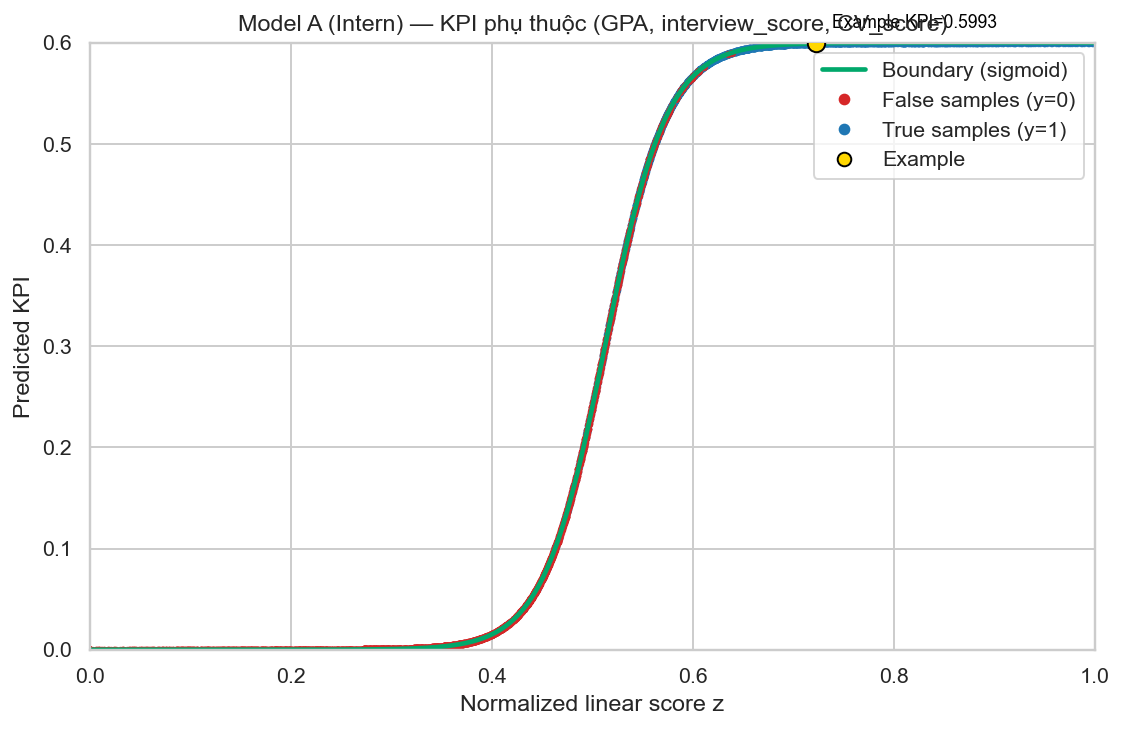

Saved: D:\DoAnTotNghiep\HM\output\lr_A_sigmoid_vector_style.png


In [41]:
# Model A image (limit KPI: 0 -> 0.6)

FEATURES_A = ["GPA", "interview_score", "CV_score"]
df_a = load_csv("data_A.csv")
# 3.35,6.73,6.73
example_a = {
    "GPA": 3.35,
    "interview_score": 6.73,
    "CV_score": 6.73,
}

_plot_sigmoid_style_report(
    model_key="A",
    df=df_a,
    feature_cols=FEATURES_A,
    kpi_threshold=float(KPI_TRAIN_THRESHOLD_A),
    title="Model A (Intern) — KPI phụ thuộc (GPA, interview_score, CV_score)",
    out_name="lr_A_sigmoid_vector_style.png",
    example_vector=example_a,
)

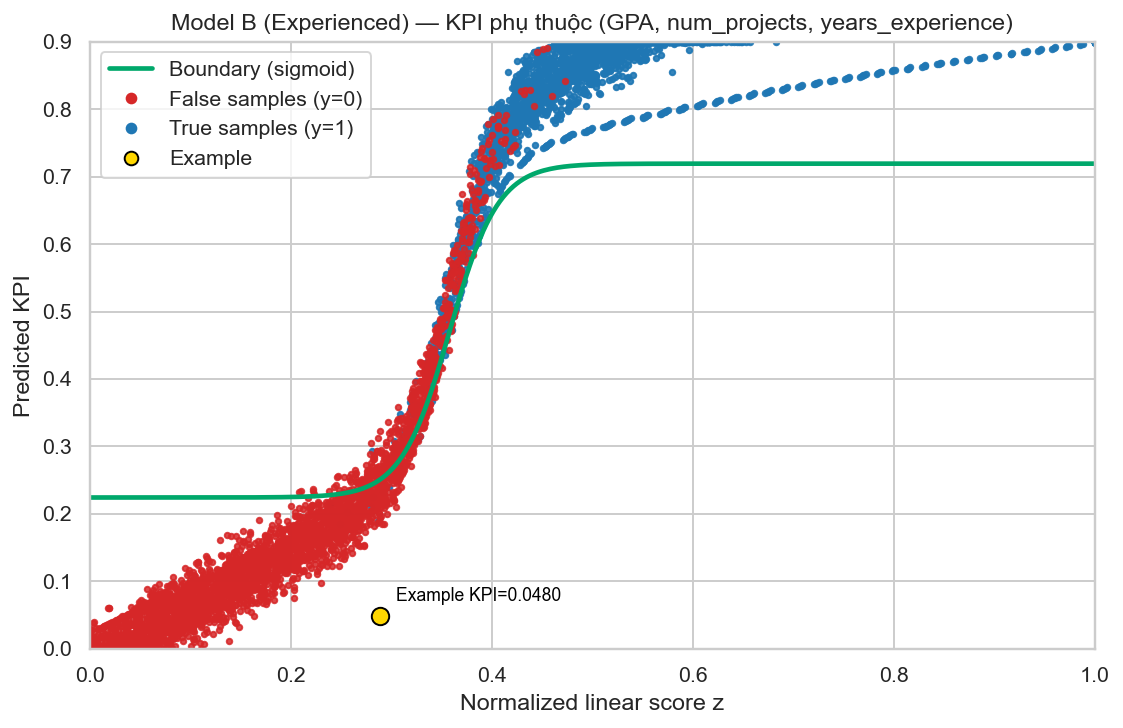

Saved: D:\DoAnTotNghiep\HM\output\lr_B_sigmoid_vector_style.png


In [36]:
# Model B image (limit KPI: 0 -> 0.9)

FEATURES_B = ["GPA", "num_projects", "years_experience"]
df_b = load_csv("data_B.csv")

example_b = {
    "GPA": 3.55,
    "num_projects": 20,
    "years_experience": 2,
}

_plot_sigmoid_style_report(
    model_key="B",
    df=df_b,
    feature_cols=FEATURES_B,
    kpi_threshold=0.5,
    title="Model B (Experienced) — KPI phụ thuộc (GPA, num_projects, years_experience)",
    out_name="lr_B_sigmoid_vector_style.png",
    example_vector=example_b,
)

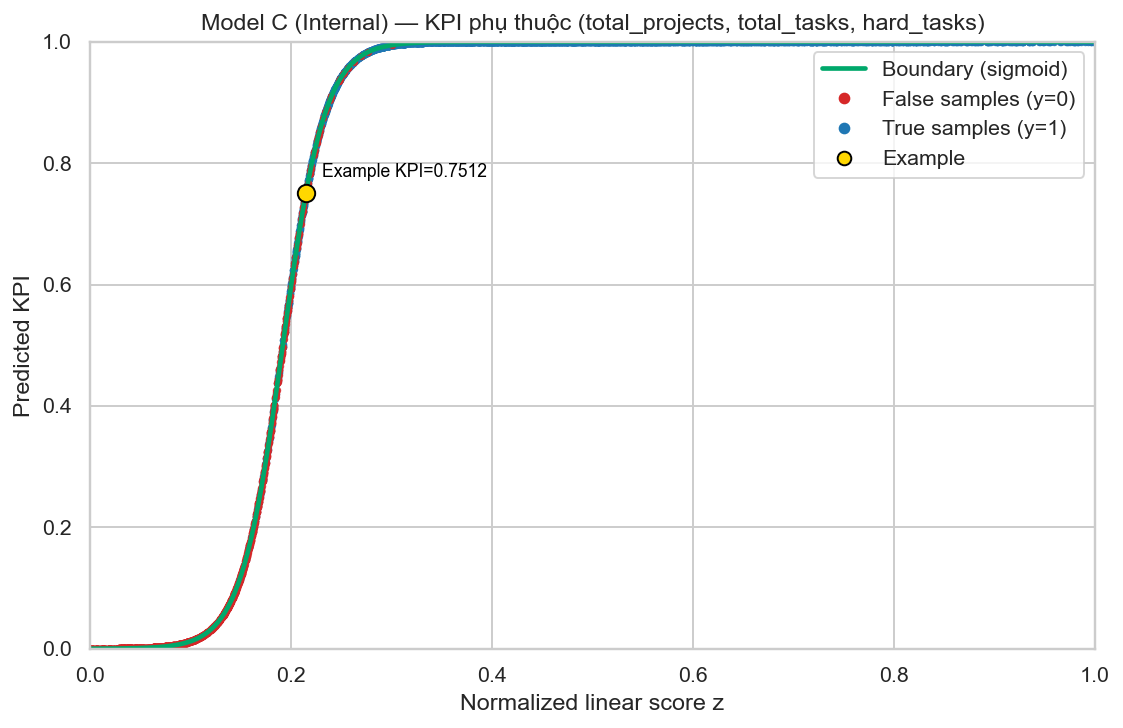

Saved: D:\DoAnTotNghiep\HM\output\lr_C_sigmoid_vector_style.png


In [33]:
# Model C image (limit KPI: 0 -> 1.0)

FEATURES_C = ["total_projects", "total_tasks", "hard_tasks"]
df_c = load_csv("data_C.csv")

example_c = {
    "total_projects": 6,
    "total_tasks": 120,
    "hard_tasks": 16,
}

_plot_sigmoid_style_report(
    model_key="C",
    df=df_c,
    feature_cols=FEATURES_C,
    kpi_threshold=0.5,
    title="Model C (Internal) — KPI phụ thuộc (total_projects, total_tasks, hard_tasks)",
    out_name="lr_C_sigmoid_vector_style.png",
    example_vector=example_c,
)